# Weight/mass loss Preprocessing

**Author:** Lab of Farm Structures
**Date:** 2026-01

## Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
import math
import re

## Import Data

In [2]:
database = 'scl_weight_loss_data_library_raw_LM'

## Create DataFrames for data points and properties

In [3]:
# Physicochemical properties DataFrame
df_physicochem = pd.read_excel(f'{database}.xlsx', sheet_name='Physicochemical properties')

# Environmental properties DataFrame
df_environment = pd.read_excel(f'{database}.xlsx', sheet_name='Environmental Properties')

# weight loss percentage DataFrame
df_weight = pd.read_excel(f'{database}.xlsx', sheet_name='Y_weight_mass_loss_%')

# Time points degradation DataFrame
df_time = pd.read_excel(f'{database}.xlsx', sheet_name='X_degradation_time_points')

## Drop duplicates and remove multiple study+instance case (keep first)

In [4]:
print("Enviromental Properties, rows before:", df_environment.shape[0])
df_environment = df_environment.drop_duplicates()
print("Enviromental Properties, rows after:", df_environment.shape[0])

Enviromental Properties, rows before: 197
Enviromental Properties, rows after: 158


In [5]:
print("Physicochemical Properties, rows before:", df_physicochem.shape[0])
df_physicochem = df_physicochem.drop_duplicates(subset=['Study_id', 'Instance'])
print("Physicochemical Properties, rows after:", df_physicochem.shape[0])

Physicochemical Properties, rows before: 474
Physicochemical Properties, rows after: 159


## Merge physicochemical & enviromental properties

In [6]:
df_merged_prop = pd.merge(df_physicochem, df_environment,  on=['Study_id', 'Instance'], how='left')
df_merged_prop.tail()

,Study_id,Instance,Sample_name,{Sample ratio wt/wt%},Monomer_A,Monomer_B,Adjusted_HB_ratio_formulation (mol%),Adjusted_HV_ratio_formulation (mol%),Additives,Additive1_name,...,Compost_T,TOCA %,TNA %,TDS %,C/N,VS %,PHA_degrading_microbes,Degradation_Environment,Experimental_Scale,ASTM/ISO
154,24.0,5,PHBV,100/0,PHB,PHV,98.50,1.50,No,NaN,...,NaN,0.13,NaN,NaN,NaN,NaN,bacteria and possibly fungi or algae,marine,lab,UNE-ISO 23977-1
155,24.0,6,PHBV_c,95/5,PHB,PHV,93.58,1.43,Yes,Catechin,...,NaN,0.13,NaN,NaN,NaN,NaN,bacteria and possibly fungi or algae,marine,lab,UNE-ISO 23977-1
156,24.0,7,PHBV_f,95/5,PHB,PHV,93.58,1.43,Yes,Ferulic Acid,...,NaN,0.13,NaN,NaN,NaN,NaN,bacteria and possibly fungi or algae,marine,lab,UNE-ISO 23977-1
157,24.0,8,PHBV_v,95/5,PHB,PHV,93.58,1.43,Yes,Vanillin,...,NaN,0.13,NaN,NaN,NaN,NaN,bacteria and possibly fungi or algae,marine,lab,UNE-ISO 23977-1
158,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Melt t values

In [7]:
id_cols = ["Study_id", "Instance", "Sample_name"]

value_cols = [c for c in df_time.columns if c not in id_cols]

df_time[value_cols] = df_time[value_cols].apply(
    pd.to_numeric, errors="coerce"
)
t_long = (
    df_time
    .set_index(id_cols)[value_cols]
    .stack()
    .reset_index(level=-1, drop=True)
    .reset_index(name="t_value")
)
t_long = t_long.dropna(subset=["t_value"])
t_long.tail()

,Study_id,Instance,Sample_name,t_value
1541,24,8,PHBV_v,135.39864
1542,24,8,PHBV_v,141.95900
1543,24,8,PHBV_v,148.51937
1544,24,8,PHBV_v,155.07973
1545,24,8,PHBV_v,161.64009


## Melt y values

In [8]:
id_cols = ["Study_id", "Instance", "Sample_name"]

value_cols = [c for c in df_weight.columns if c not in id_cols]

df_weight[value_cols] = df_weight[value_cols].apply(
    pd.to_numeric, errors="coerce"
)
y_long = (
    df_weight
    .set_index(id_cols)[value_cols]
    .stack()
    .reset_index(level=-1, drop=True)
    .reset_index(name="y_value")
)
y_long = y_long.dropna(subset=["y_value"])
y_long.tail()

,Study_id,Instance,Sample_name,y_value
1541,24,8,PHBV_v,73.65600
1542,24,8,PHBV_v,74.60585
1543,24,8,PHBV_v,75.55571
1544,24,8,PHBV_v,76.26810
1545,24,8,PHBV_v,76.98050


## Merge t and y values

In [9]:
t_long = t_long.reset_index(drop=True)
y_long = y_long.reset_index(drop=True)
ty_df = pd.concat(
    [
        t_long[["Study_id", "Instance", "Sample_name", "t_value"]],
        y_long[["y_value"]]
    ],
    axis=1
)
ty_df.tail()

,Study_id,Instance,Sample_name,t_value,y_value
1541,24,8,PHBV_v,135.39864,73.65600
1542,24,8,PHBV_v,141.95900,74.60585
1543,24,8,PHBV_v,148.51937,75.55571
1544,24,8,PHBV_v,155.07973,76.26810
1545,24,8,PHBV_v,161.64009,76.98050


## Merge properties with t,y values

In [10]:
df_merged_fnl = df_merged_prop.merge(
    ty_df[['Study_id', 'Instance', 't_value', 'y_value']],
    on=['Study_id', 'Instance'],
    how='left'
)
df_merged_fnl = df_merged_fnl.dropna(subset=['t_value', 'y_value'])
df_merged_fnl.tail()

,Study_id,Instance,Sample_name,{Sample ratio wt/wt%},Monomer_A,Monomer_B,Adjusted_HB_ratio_formulation (mol%),Adjusted_HV_ratio_formulation (mol%),Additives,Additive1_name,...,TNA %,TDS %,C/N,VS %,PHA_degrading_microbes,Degradation_Environment,Experimental_Scale,ASTM/ISO,t_value,y_value
1566,24.0,8,PHBV_v,95/5,PHB,PHV,93.58,1.43,Yes,Vanillin,...,NaN,NaN,NaN,NaN,bacteria and possibly fungi or algae,marine,lab,UNE-ISO 23977-1,135.39864,73.65600
1567,24.0,8,PHBV_v,95/5,PHB,PHV,93.58,1.43,Yes,Vanillin,...,NaN,NaN,NaN,NaN,bacteria and possibly fungi or algae,marine,lab,UNE-ISO 23977-1,141.95900,74.60585
1568,24.0,8,PHBV_v,95/5,PHB,PHV,93.58,1.43,Yes,Vanillin,...,NaN,NaN,NaN,NaN,bacteria and possibly fungi or algae,marine,lab,UNE-ISO 23977-1,148.51937,75.55571
1569,24.0,8,PHBV_v,95/5,PHB,PHV,93.58,1.43,Yes,Vanillin,...,NaN,NaN,NaN,NaN,bacteria and possibly fungi or algae,marine,lab,UNE-ISO 23977-1,155.07973,76.26810
1570,24.0,8,PHBV_v,95/5,PHB,PHV,93.58,1.43,Yes,Vanillin,...,NaN,NaN,NaN,NaN,bacteria and possibly fungi or algae,marine,lab,UNE-ISO 23977-1,161.64009,76.98050


## Rename t and y values

In [11]:
df_merged_fnl = df_merged_fnl.rename(columns={
    't_value': 'degradation_time_(days)',
    'y_value': 'weight_loss_%'
})

df_merged_fnl.columns

Index(['Study_id', 'Instance', ' Sample_name', '{Sample ratio wt/wt%}',
       'Monomer_A', 'Monomer_B', 'Adjusted_HB_ratio_formulation (mol%)',
       'Adjusted_HV_ratio_formulation (mol%) ', 'Additives', 'Additive1_name',
       'Additive_type_1', 'Additive1_percentage (wt%)', 'Additive2_name',
       'Additive_type_2', 'Additive2_percentage (wt%)', 'Additive3_name',
       'Additive_type_3', 'Additive3_percentage (wt%)',
       'PHBV_weight_percentage_final_formulation (wt%)',
       'Viscocimetric_molar_mass, Mv (g/mol)',
       'Soil_burial_time_for_Mv (months)', 'Mw (kDa)',
       'Soil_burial_time_for_Mw (months)', 'Relative_Mw (%)',
       'Incubation_time_for_relative_Mw (days)', 'Mn (kDa)',
       'Soil_burial_time_for_Mn (months)', 'PDI ',
       'Soil_burial_time_for_PDI (months)',
       'Moisture_content_formulations (%)',
       'Soil_burial_time _for_moisture_content (months)', 'Density',
       'Density_units', 'Void_content (%)', 'Sample_shape/Morphology',
       'Siz

## Drop duplicates

In [12]:
df_merged_fnl = df_merged_fnl.drop_duplicates()

## Replace N/A values with nan

In [13]:
df_merged_fnl = df_merged_fnl.replace(
    ["N/A", "n/a", "NA", "na"],
    np.nan
)

In [14]:
df_merged_fnl = df_merged_fnl.drop(columns=['Sample_name'])
df_merged_fnl.columns

Index(['Study_id', 'Instance', ' Sample_name', '{Sample ratio wt/wt%}',
       'Monomer_A', 'Monomer_B', 'Adjusted_HB_ratio_formulation (mol%)',
       'Adjusted_HV_ratio_formulation (mol%) ', 'Additives', 'Additive1_name',
       'Additive_type_1', 'Additive1_percentage (wt%)', 'Additive2_name',
       'Additive_type_2', 'Additive2_percentage (wt%)', 'Additive3_name',
       'Additive_type_3', 'Additive3_percentage (wt%)',
       'PHBV_weight_percentage_final_formulation (wt%)',
       'Viscocimetric_molar_mass, Mv (g/mol)',
       'Soil_burial_time_for_Mv (months)', 'Mw (kDa)',
       'Soil_burial_time_for_Mw (months)', 'Relative_Mw (%)',
       'Incubation_time_for_relative_Mw (days)', 'Mn (kDa)',
       'Soil_burial_time_for_Mn (months)', 'PDI ',
       'Soil_burial_time_for_PDI (months)',
       'Moisture_content_formulations (%)',
       'Soil_burial_time _for_moisture_content (months)', 'Density',
       'Density_units', 'Void_content (%)', 'Sample_shape/Morphology',
       'Siz

## Fix typos, excl. special characters

In [15]:
def clean_column_name(col):
    col = col.strip().lower()
    col = re.sub(r'[%()]', '', col)        # remove % ( )
    col = re.sub(r'[\/]', '_', col)        # / → _
    col = re.sub(r'\s+', '_', col)         # spaces → _
    col = re.sub(r'[^a-z0-9_]', '', col)   # remove remaining special chars
    col = re.sub(r'_+', '_', col)           # collapse multiple _
    col = col.strip('_')
    return col

def clean_cell_value(val):
    if isinstance(val, str):
        val = val.strip().lower()
        val = re.sub(r'[%()]', '', val)       # remove % ( )
        val = re.sub(r'[\/]', '_', val)       # / → _
        val = re.sub(r'\s+', '_', val)        # spaces → _
        val = re.sub(r'[^a-z0-9_]', '', val)  # remove remaining special chars
        val = re.sub(r'_+', '_', val)         # collapse multiple _
        val = val.strip('_')
    return val

In [16]:
df_merged_fnl.columns = [clean_column_name(c) for c in df_merged_fnl.columns]
df_merged_fnl.head()

,study_id,instance,sample_name,sample_ratio_wt_wt,monomer_a,monomer_b,adjusted_hb_ratio_formulation_mol,adjusted_hv_ratio_formulation_mol,additives,additive1_name,...,tna,tds,c_n,vs,pha_degrading_microbes,degradation_environment,experimental_scale,astm_iso,degradation_time_days,weight_loss
0,4.0,5,PCA20: PHBV/CaCO3/ATBC/PO,66.5/3.5/10/20,PHB,PHV,63.2,3.3,Yes,ATBC: acetyl tributyl citrate,...,NaN,NaN,NaN,NaN,bacteria and fungi,marine,Large,NaN,30.0,2.69511
1,4.0,5,PCA20: PHBV/CaCO3/ATBC/PO,66.5/3.5/10/20,PHB,PHV,63.2,3.3,Yes,ATBC: acetyl tributyl citrate,...,NaN,NaN,NaN,NaN,bacteria and fungi,marine,Large,NaN,60.0,4.61221
2,4.0,5,PCA20: PHBV/CaCO3/ATBC/PO,66.5/3.5/10/20,PHB,PHV,63.2,3.3,Yes,ATBC: acetyl tributyl citrate,...,NaN,NaN,NaN,NaN,bacteria and fungi,marine,Large,NaN,90.0,6.68475
3,4.0,5,PCA20: PHBV/CaCO3/ATBC/PO,66.5/3.5/10/20,PHB,PHV,63.2,3.3,Yes,ATBC: acetyl tributyl citrate,...,NaN,NaN,NaN,NaN,bacteria and fungi,marine,Large,NaN,150.0,9.58630
4,4.0,5,PCA20: PHBV/CaCO3/ATBC/PO,66.5/3.5/10/20,PHB,PHV,63.2,3.3,Yes,ATBC: acetyl tributyl citrate,...,NaN,NaN,NaN,NaN,bacteria and fungi,marine,Large,NaN,240.0,11.76247


In [17]:
df_clean = df_merged_fnl.copy()

# apply only to object (string) columns
obj_cols = df_clean.select_dtypes(include='object').columns

df_clean[obj_cols] = df_clean[obj_cols].apply( lambda col: col.map(clean_cell_value) )

In [18]:
df_clean['additive_type_1'] = df_clean['additive_type_1'].replace(' filler', 'filler')

df_clean.loc[df_clean['additive1_percentage_wt'].isna(), 'additive1_percentage_wt'] = 0
df_clean.loc[df_clean['additive2_percentage_wt'].isna(), 'additive2_percentage_wt'] = 0
df_clean.loc[df_clean['additive3_percentage_wt'].isna(), 'additive3_percentage_wt'] = 0

In [19]:
df_clean['additive1_percentage_wt'] = pd.to_numeric(df_clean['additive1_percentage_wt'],errors='coerce')
df_clean['additive2_percentage_wt'] = pd.to_numeric(df_clean['additive2_percentage_wt'],errors='coerce')
df_clean['additive3_percentage_wt'] = pd.to_numeric(df_clean['additive3_percentage_wt'],errors='coerce')

df_clean['additive1'] = df_clean['additive1_percentage_wt'].apply(lambda x: 'yes' if x > 0 else 'no')
df_clean['additive2'] = df_clean['additive2_percentage_wt'].apply(lambda x: 'yes' if x > 0 else 'no')
df_clean['additive3'] = df_clean['additive3_percentage_wt'].apply(lambda x: 'yes' if x > 0 else 'no')

df_clean.loc[df_clean['additive1'] == 'no', 'additive_type_1'] = 'not_applicable'
df_clean.loc[df_clean['additive2'] == 'no', 'additive_type_2'] = 'not_applicable'
df_clean.loc[df_clean['additive3'] == 'no', 'additive_type_3'] = 'not_applicable'

## Drop features with more than 80% missing values

In [20]:
df_clean = df_clean.loc[:, df_clean.isna().mean() < 0.20]
df_clean.columns

Index(['study_id', 'instance', 'sample_name', 'sample_ratio_wt_wt',
       'monomer_a', 'monomer_b', 'adjusted_hb_ratio_formulation_mol',
       'adjusted_hv_ratio_formulation_mol', 'additives', 'additive1_name',
       'additive_type_1', 'additive1_percentage_wt', 'additive_type_2',
       'additive2_percentage_wt', 'additive_type_3', 'additive3_percentage_wt',
       'phbv_weight_percentage_final_formulation_wt',
       'sample_shape_morphology', 'parameter_evaluated',
       'degradation_condition', 'degradation_mechanism', 't_deg',
       't_deg_units', 'pha_degrading_microbes', 'degradation_environment',
       'experimental_scale', 'degradation_time_days', 'weight_loss',
       'additive1', 'additive2', 'additive3'],
      dtype='object')

## Feature engineering

In [21]:
df_clean['experimental_scale'].value_counts()

experimental_scale
large    960
lab      586
Name: count, dtype: int64

In [22]:
df_clean['degradation_mechanism'].value_counts()

degradation_mechanism
microbial_biodegradation                                       418
enzymemediated_microbial_biodegradation                        406
hydrolysisassisted_microbial_assimilation                      337
surface_erosion_driven_biodegradation                          142
surface_erosiondriven_biodegradation                           131
hydrolysis_assisted_microbial_assimilation                      77
environmentally_modified_microbial_degradation                  14
crackenhanced_microbial_biodegradation                           9
stabilization_or_degradation_inhibition_due_to_crosslinking      8
hydrolytic_degradation                                           4
Name: count, dtype: int64

In [23]:
degradation_mapping = {
    "microbial_biodegradation": "microbial_enzymatic",
    "enzymemediated_microbial_biodegradation": "microbial_enzymatic",
    "hydrolysisassisted_microbial_assimilation": "hydrolysis",
    "hydrolysis_assisted_microbial_assimilation": "hydrolysis",
    "hydrolytic_degradation": "hydrolysis",
    "surface_erosiondriven_biodegradation": "surface",
    "surface_erosion_driven_biodegradation": "surface",
    "crackenhanced_microbial_biodegradation": "surface",
    "environmentally_modified_microbial_degradation": "other",
    "stabilization_or_degradation_inhibition_due_to_crosslinking": "other"
}

# Apply mapping
df_clean["degradation_mechanism"] = (
    df_clean["degradation_mechanism"]
    .str.strip()           # remove leading/trailing spaces
    .map(degradation_mapping)
    .fillna("uncategorized")
)

In [24]:
df_clean['degradation_mechanism'].value_counts()

degradation_mechanism
microbial_enzymatic    824
hydrolysis             418
surface                282
other                   22
Name: count, dtype: int64

In [25]:
df_clean['sample_shape_morphology'].value_counts()

sample_shape_morphology
flat_ribbons                      404
films                             385
biocomposite_sheets               221
circular_blend_films              192
sheets                            124
laminates                          73
flat_plates_and_thin_films         70
thin_films                         24
filaments_pellets                  14
rectangular_strips_flat_sheets     14
films_spherulite_morphologies       9
ribbons                             6
spherulites                         6
rectangular_plates                  4
Name: count, dtype: int64

In [26]:
morphology_mapping = {
    "flat_ribbons": "ribbons",
    "films":"films",
    "biocomposite_sheets": "sheets",
    "circular_blend_films": "films",
    "laminates": "sheets",
    "sheets": "sheets",
    "flat_plates_and_thin_films": "films",
    "thin_films": "films",
    "rectangular_plates": "sheets",
    "filaments_pellets": "other",
    "rectangular_strips_flat_sheets": "sheets",
    "ribbons":"ribbons",
    "films_spherulite_morphologies": "other",
    "spherulites": "other"
}

In [27]:
df_clean["sample_shape_morphology"] = (
    df_clean["sample_shape_morphology"]
    .str.strip()  # remove leading/trailing whitespace
    .map(morphology_mapping)
    .fillna("uncategorized")
)
df_clean["sample_shape_morphology"].value_counts()

sample_shape_morphology
films      671
sheets     436
ribbons    410
other       29
Name: count, dtype: int64

In [28]:
df_clean['pha_degrading_microbes'].value_counts()

pha_degrading_microbes
bacteria_and_fungi                                                                                                                                                                         483
unspecified_marine_bacteria                                                                                                                                                                404
the_phas_degraders_were_identified_from_genus_cupriavidus_acidovorax_variovora_streptomyces_and_ideonella_and_two_starch_degraders_were_identified_from_genus_moraxella_and_alcaligenes    192
diverse_microbial_community                                                                                                                                                                 93
bacteria_and_possibly_fungi_or_algae                                                                                                                                                        84
fungi_yeasts_and_bacte

In [29]:
pha_microbe_mapping = {
    "bacteria_and_fungi": "bacteria_dominated",
    "unspecified_marine_bacteria": "bacteria_dominated",
    "the_phas_degraders_were_identified_from_genus_cupriavidus_acidovorax_variovora_streptomyces_and_ideonella_and_two_starch_degraders_were_identified_from_genus_moraxella_and_alcaligenes": "bacteria_dominated",
    "mixed_mostly_bacteria": "bacteria_dominated",
    "p_mendocina_ds04t": "bacteria_dominated",
    "marine_bacteria": "bacteria_dominated",
    "thermophilic_bacteria_fungi": "bacteria_dominated",
    "fungi": "fungi_dominated",
    "fungal_mycelium": "fungi_dominated",
    "fungal_hyphae_and_spores": "fungi_dominated",
    "fungi_yeasts_and_bacteria": "bacteria_fungi_mixed",
    "bacteria_fungi_actinomycetes": "bacteria_fungi_mixed",
    "bacteria_actinomycetes_streptomyces_and_fungal_mycelium": "bacteria_fungi_mixed",
    "mixed_bacteria_fungi": "bacteria_fungi_mixed",
    "diverse_microbial_community": "diverse_environmental",
    "aquatic_microbes_bacteria_algae_etc": "diverse_environmental",
    "bacteria_and_possibly_fungi_or_algae": "diverse_environmental",
    "mesophilic_microbes_eisenia_foetida": "uncategorized"
}

In [30]:
df_clean["pha_degrading_microbes"] = (
    df_clean["pha_degrading_microbes"]
    .str.strip()  # remove leading/trailing whitespace
    .map(pha_microbe_mapping)
    .fillna("uncategorized")
)
df_clean["pha_degrading_microbes"].value_counts()

pha_degrading_microbes
bacteria_dominated       1114
bacteria_fungi_mixed      182
diverse_environmental     181
fungi_dominated            61
uncategorized               8
Name: count, dtype: int64

In [31]:
df_clean['degradation_environment'].value_counts()

degradation_environment
soil                     572
marine                   508
industrial_compost       126
compost                  110
liquid_mineral_medium    102
freshwater               100
field_soil                14
organic_fertilizer         6
vermicompost               4
thermophilic_compost       4
Name: count, dtype: int64

In [32]:
origin_mapping = {
    "soil":"soil",
    "field_soil": "soil",
    "marine": "marine_aquatic",
    "freshwater": "marine_aquatic",
    "industrial_compost": "compost_organic_fertilizer",
    "compost": "compost_organic_fertilizer",
    "thermophilic_compost": "compost_organic_fertilizer",
    "vermicompost": "compost_organic_fertilizer",
    "organic_fertilizer": "compost_organic_fertilizer",
    "liquid_mineral_medium": "laboratory_mineral_media"
}

# Apply mapping
df_clean["degradation_environment"] = (
    df_clean["degradation_environment"]
    .str.strip()  # remove leading/trailing spaces
    .map(origin_mapping)
    .fillna("other")
)

# check counts
df_clean["degradation_environment"].value_counts()

degradation_environment
marine_aquatic                608
soil                          586
compost_organic_fertilizer    250
laboratory_mineral_media      102
Name: count, dtype: int64

In [33]:
df_clean["additive_type_1"].value_counts()

additive_type_1
plasticizer       598
filler            353
not_applicable    345
reinforcement     221
crosslinker        20
blend_polymer       9
Name: count, dtype: int64

In [34]:
additive_mapping = {
    "plasticizer": "plasticizer",
    "filler": "filler",
    "reinforcement": "reinforcement",
    "crosslinker": "crosslinker_polymer_modifier",
    "blend_polymer": "crosslinker_polymer_modifier",
    "not_applicable": "not_applicable"
}

# Apply mapping
df_clean["additive_type_1"] = (
    df_clean["additive_type_1"]
    .str.strip()  # remove leading/trailing spaces
    .map(additive_mapping)
    .fillna("uncategorized")
)

# check counts
df_clean["additive_type_1"].value_counts()

additive_type_1
plasticizer                     598
filler                          353
not_applicable                  345
reinforcement                   221
crosslinker_polymer_modifier     29
Name: count, dtype: int64

## Feature selection and Target value

In [35]:
features = [
    'study_id',
    'instance',
    'adjusted_hb_ratio_formulation_mol',
    'adjusted_hv_ratio_formulation_mol',
    'degradation_time_days',
    'degradation_condition',
    'degradation_mechanism',
    'additives',
    't_deg',
    'degradation_environment',
    'additive_type_1',
    'additive1_percentage_wt',
    'additive_type_2',
    'additive2_percentage_wt',
    'additive_type_3',
    'additive3_percentage_wt',
    'sample_shape_morphology',
    'pha_degrading_microbes',
    'experimental_scale'
]

target = 'weight_loss'

measure_unit = '%'

In [36]:
# Create cleaned DataFrame
df_new = df_clean[features + [target]]

df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1546 entries, 0 to 1570
Data columns (total 20 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   study_id                           1546 non-null   float64
 1   instance                           1546 non-null   object 
 2   adjusted_hb_ratio_formulation_mol  1540 non-null   float64
 3   adjusted_hv_ratio_formulation_mol  1540 non-null   float64
 4   degradation_time_days              1546 non-null   float64
 5   degradation_condition              1546 non-null   object 
 6   degradation_mechanism              1546 non-null   object 
 7   additives                          1546 non-null   object 
 8   t_deg                              1263 non-null   float64
 9   degradation_environment            1546 non-null   object 
 10  additive_type_1                    1546 non-null   object 
 11  additive1_percentage_wt            1473 non-null   float64
 1

## Fill in missing Temperatures: t_deg

In [37]:
missing_counts = df_new['t_deg'].isna().groupby(df_new['study_id']).sum()
missing_counts.sort_values(ascending=False)

study_id
5.0     192
14.0     77
4.0      14
21.0      0
20.0      0
19.0      0
18.0      0
16.0      0
15.0      0
13.0      0
12.0      0
11.0      0
10.0      0
9.0       0
8.0       0
6.0       0
24.0      0
Name: t_deg, dtype: int64

In [38]:
df_new[df_new['study_id']==4]['degradation_environment'].value_counts()

degradation_environment
marine_aquatic    14
Name: count, dtype: int64

In [39]:
mask_fill1 = (df_new['study_id'] == 4) & (df_new['degradation_environment'] == 'marine_aquatic')

mean_value1 = df_new.loc[
    (df_new['study_id'] != 4) & (df_new['degradation_environment'] == 'marine_aquatic'),
    't_deg'
].mean()

df_new.loc[mask_fill1, 't_deg'] = mean_value1

In [40]:
df_new[df_new['study_id']==5]['degradation_environment'].value_counts()

degradation_environment
soil              96
marine_aquatic    96
Name: count, dtype: int64

In [41]:
mask_fill2 = (df_new['study_id'] == 5) & (df_new['degradation_environment'] == 'marine_aquatic')
mask_fill3 = (df_new['study_id'] == 5) & (df_new['degradation_environment'] == 'soil')

mean_value2 = df_new.loc[
    (df_new['study_id'] != 5) & (df_new['degradation_environment'] == 'soil'),
    't_deg'
].mean()

df_new.loc[mask_fill2, 't_deg'] = mean_value1
df_new.loc[mask_fill3, 't_deg'] = mean_value2

In [42]:
df_new[df_new['study_id']==5]['t_deg'].value_counts()

t_deg
26.539467    96
27.335341    96
Name: count, dtype: int64

In [43]:
df_new[df_new['study_id']==14]['degradation_environment'].value_counts()

degradation_environment
soil    77
Name: count, dtype: int64

In [44]:
mask_fill4 = (df_new['study_id'] == 14) & (df_new['degradation_environment'] == 'soil')

df_new.loc[mask_fill4, 't_deg'] = mean_value2

In [45]:
df_new[df_new['study_id']==14]['t_deg'].value_counts()

t_deg
26.539467    77
Name: count, dtype: int64

In [46]:
df_new.loc[:, 't_deg'] = df_new['t_deg'].round(1)
df_new['t_deg'].value_counts()

t_deg
29.0    463
58.0    200
26.5    173
22.9    142
27.3    110
27.0    107
30.0     93
26.0     91
25.0     84
55.0     24
60.0     16
20.0     14
23.0     10
37.0      9
28.0      6
21.0      4
Name: count, dtype: int64

## Drop rows with nan value

In [47]:
mask = (
    df_new[target].notna() &
    df_new[features].notna().all(axis=1)
)

# Create final dataset
df_final = df_new.loc[mask, features + [target]]
df_final.columns = df_final.columns.str.replace(' ', '_', regex=False)

# Check the DataFrame
df_final.tail()

,study_id,instance,adjusted_hb_ratio_formulation_mol,adjusted_hv_ratio_formulation_mol,degradation_time_days,degradation_condition,degradation_mechanism,additives,t_deg,degradation_environment,additive_type_1,additive1_percentage_wt,additive_type_2,additive2_percentage_wt,additive_type_3,additive3_percentage_wt,sample_shape_morphology,pha_degrading_microbes,experimental_scale,weight_loss
1566,24.0,8,93.58,1.43,135.39864,aerobic,hydrolysis,yes,25.0,marine_aquatic,plasticizer,5.0,not_applicable,0.0,not_applicable,0.0,films,diverse_environmental,lab,73.65600
1567,24.0,8,93.58,1.43,141.95900,aerobic,hydrolysis,yes,25.0,marine_aquatic,plasticizer,5.0,not_applicable,0.0,not_applicable,0.0,films,diverse_environmental,lab,74.60585
1568,24.0,8,93.58,1.43,148.51937,aerobic,hydrolysis,yes,25.0,marine_aquatic,plasticizer,5.0,not_applicable,0.0,not_applicable,0.0,films,diverse_environmental,lab,75.55571
1569,24.0,8,93.58,1.43,155.07973,aerobic,hydrolysis,yes,25.0,marine_aquatic,plasticizer,5.0,not_applicable,0.0,not_applicable,0.0,films,diverse_environmental,lab,76.26810
1570,24.0,8,93.58,1.43,161.64009,aerobic,hydrolysis,yes,25.0,marine_aquatic,plasticizer,5.0,not_applicable,0.0,not_applicable,0.0,films,diverse_environmental,lab,76.98050


## Process time and weight loss values, round, float, etc

In [48]:
df_final['weight_loss'] = (
    df_final['weight_loss']
    .astype(str)
    .str.replace('%', '', regex=False)
    .str.replace('±', '', regex=False)
    .str.replace(r'\s*\d+$', '', regex=True)   # remove trailing uncertainty (like "2")
    .str.strip()
)

df_final['weight_loss'] = pd.to_numeric(df_final['weight_loss'], errors='coerce')

df_final['degradation_time_days'] = (
    df_final['degradation_time_days']
    .astype(str)
    .str.replace('%', '', regex=False)
    .str.replace('±', '', regex=False)
    .str.replace(r'\s*\d+$', '', regex=True)   # remove trailing uncertainty (like "2")
    .str.strip()
)

df_final['degradation_time_days'] = pd.to_numeric(df_final['degradation_time_days'], errors='coerce')

# Convert certain values to float
df_final['degradation_time_days'] = df_final['degradation_time_days'].astype(float)
df_final['weight_loss'] = df_final['weight_loss'].astype(float)
df_final['additive3_percentage_wt'] = df_final['additive3_percentage_wt'].astype(float)

# Check the DataFrame
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1467 entries, 0 to 1570
Data columns (total 20 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   study_id                           1467 non-null   float64
 1   instance                           1467 non-null   object 
 2   adjusted_hb_ratio_formulation_mol  1467 non-null   float64
 3   adjusted_hv_ratio_formulation_mol  1467 non-null   float64
 4   degradation_time_days              1467 non-null   float64
 5   degradation_condition              1467 non-null   object 
 6   degradation_mechanism              1467 non-null   object 
 7   additives                          1467 non-null   object 
 8   t_deg                              1467 non-null   float64
 9   degradation_environment            1467 non-null   object 
 10  additive_type_1                    1467 non-null   object 
 11  additive1_percentage_wt            1467 non-null   float64
 1

## Plot feature distribution

In [49]:
# Numerical columns
numerical_cols_lst = df_final.select_dtypes(include=[np.number]).columns.tolist()
# numerical_cols_lst.remove(target)
# Categorical columns
categorical_cols_lst = df_final.select_dtypes(include=['object', 'category']).columns.tolist()

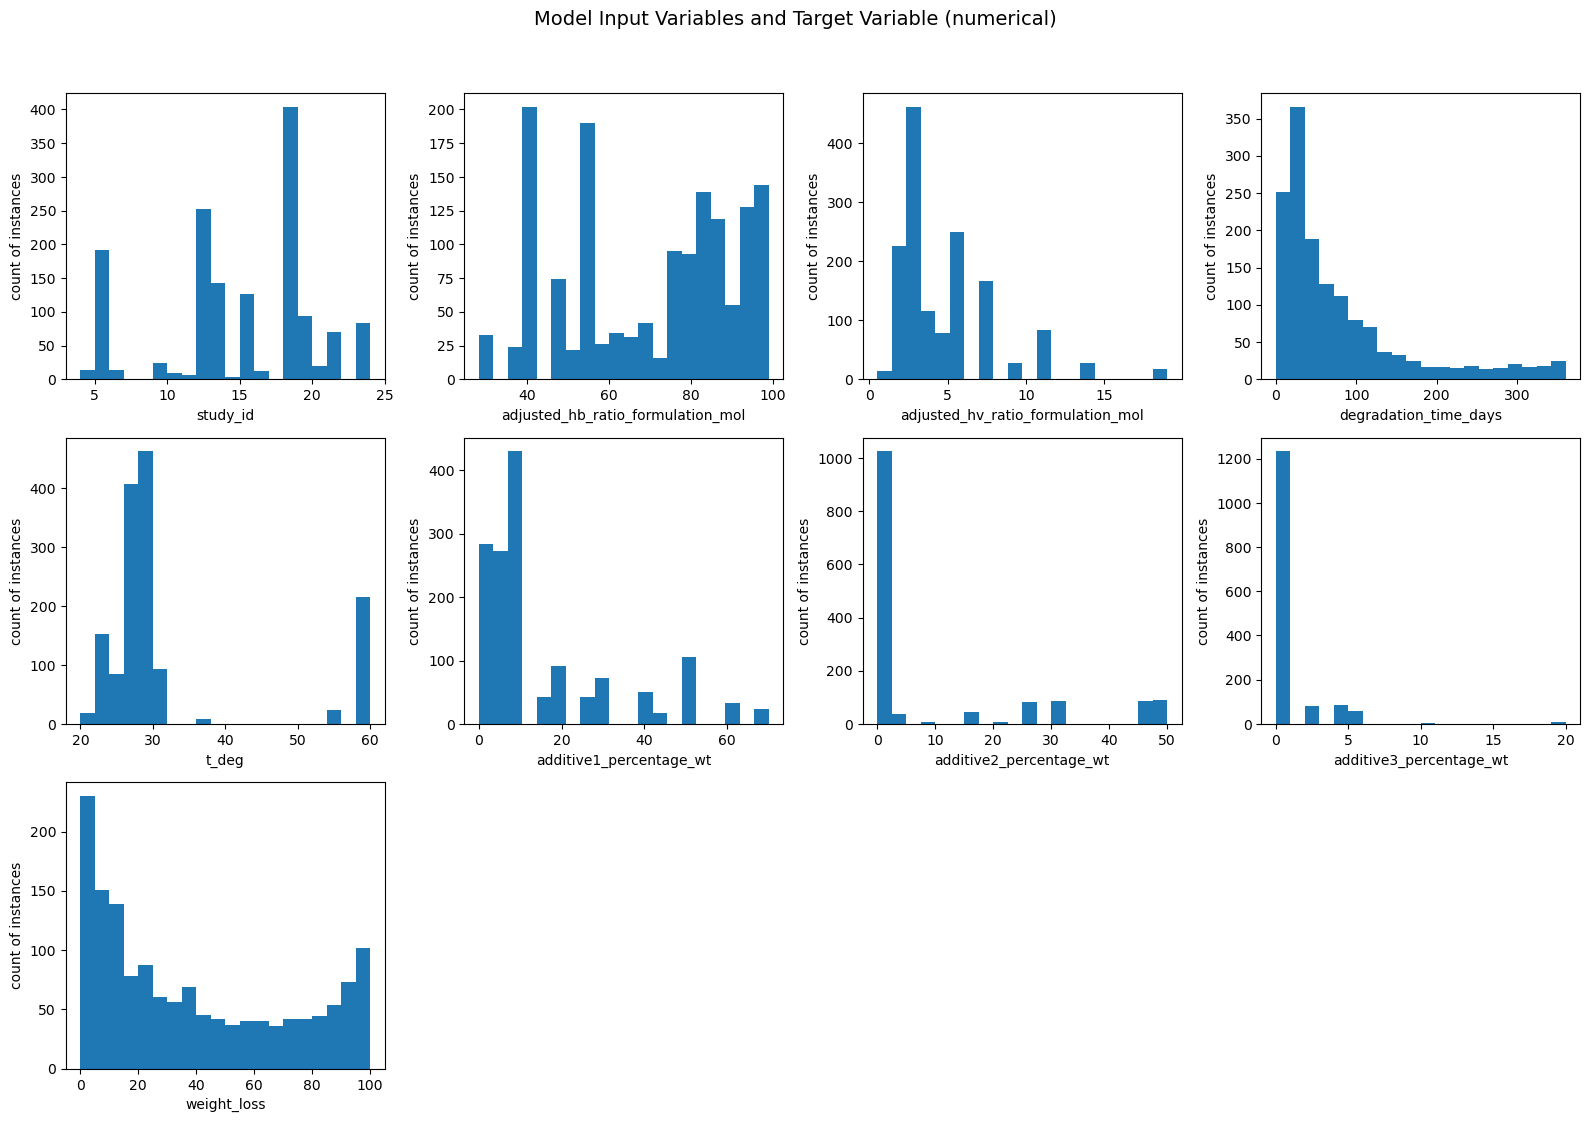

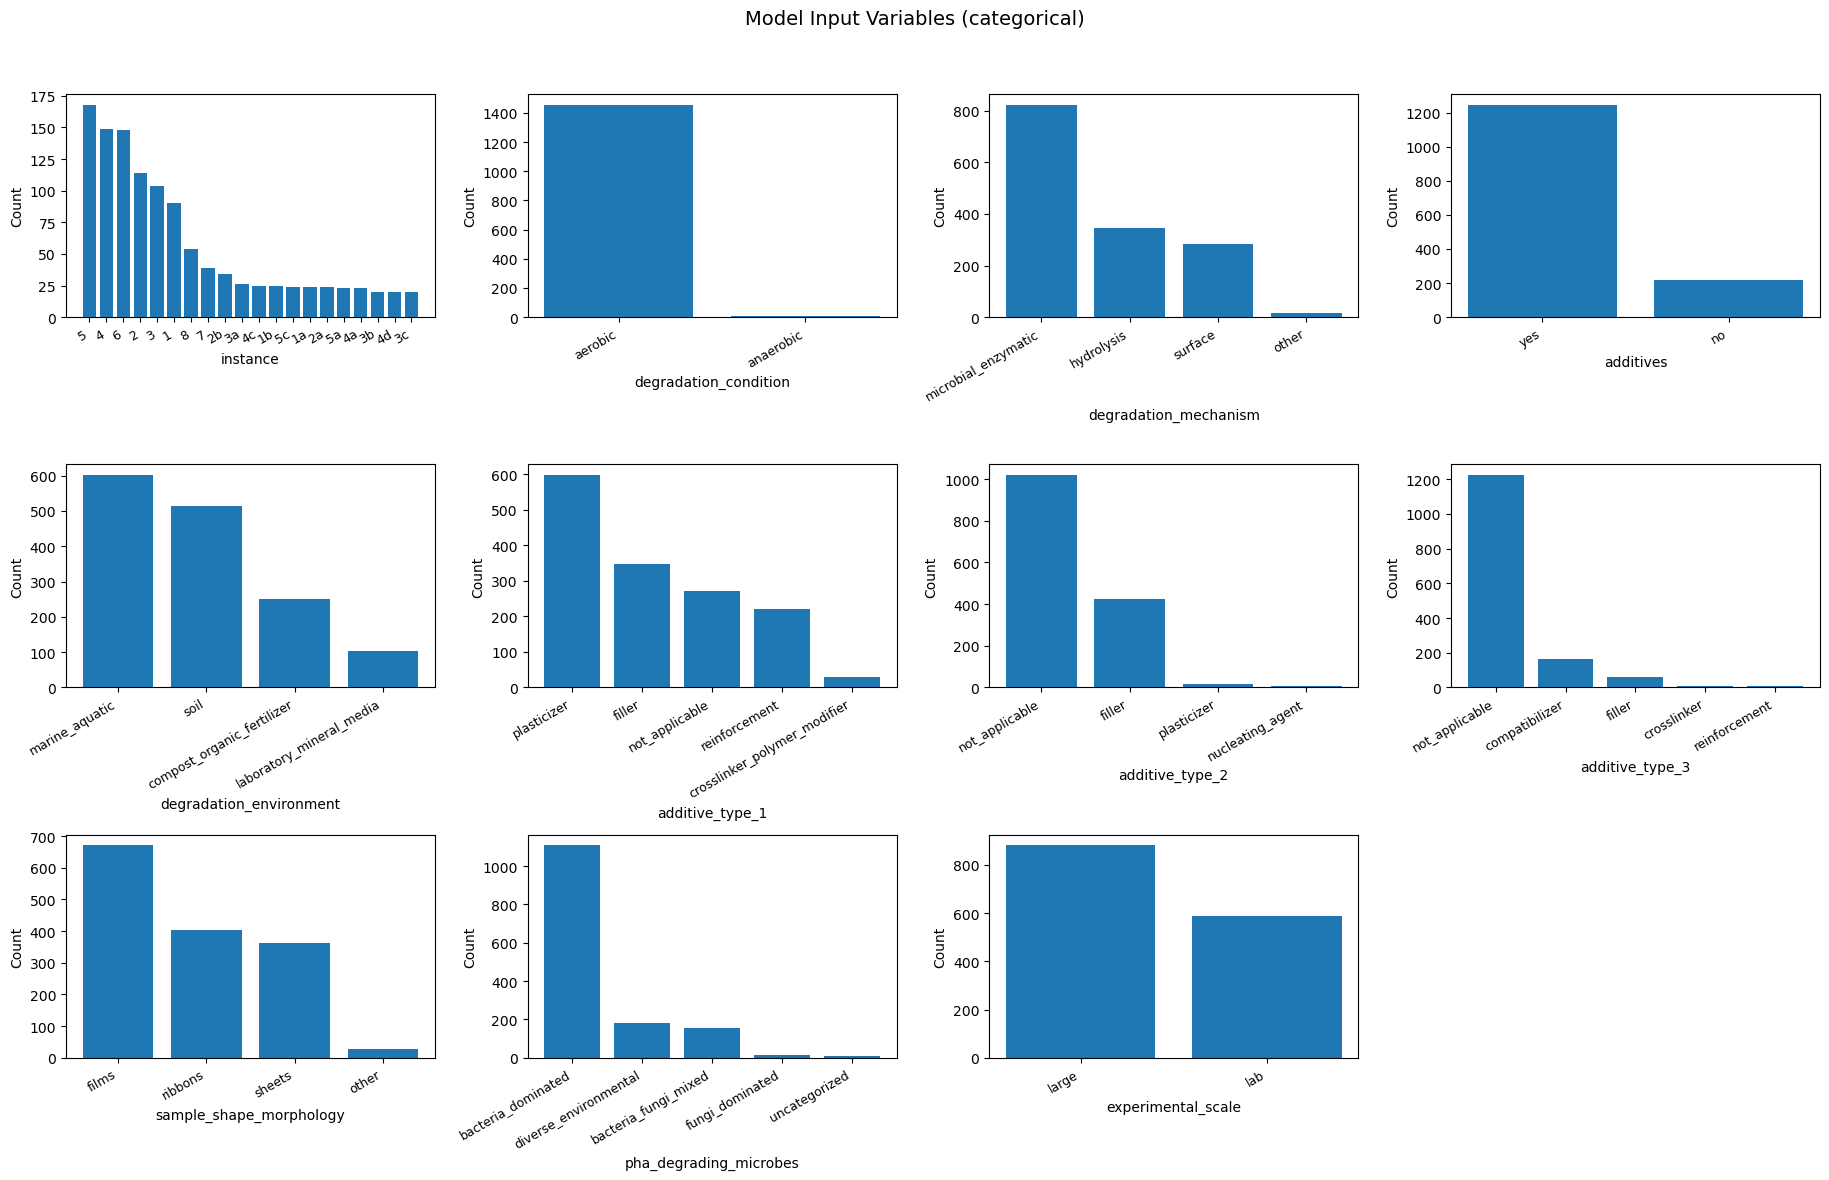

In [50]:
def plot_feature_distributions(
    df: pd.DataFrame,
    numerical_cols,
    categorical_cols,
    title_numeric="Model Input Variables and Target Variable (numerical)",
    title_categorical="Model Input Variables (categorical)",
    bins=20,
    max_cols_per_row=4,
    top_k_categories=20,   # cap bars for very high-cardinality cats
):
    # ---------- helper to grid-plot ----------
    def _grid_dims(n, max_cols):
        cols = min(max_cols, max(1, n))
        rows = int(math.ceil(n / cols))
        return rows, cols

    # ---------- NUMERICAL ----------
    if len(numerical_cols) > 0:
        n = len(numerical_cols)
        rows, cols = _grid_dims(n, max_cols_per_row)
        fig, axes = plt.subplots(rows, cols, figsize=(4.0*cols, 3.8*rows))
        axes = np.atleast_2d(axes)
        fig.suptitle(title_numeric, fontsize=14, y=0.98)

        for i, col in enumerate(numerical_cols):
            r, c = divmod(i, cols)
            ax = axes[r, c]
            x = df[col].dropna().values
            ax.hist(x, bins=bins)
            #ax.set_title(str(col), fontsize=10)
            ax.set_ylabel("count of instances")
            ax.set_xlabel(str(col))
            ax.grid(False)

        # hide any empty axes
        for j in range(n, rows*cols):
            r, c = divmod(j, cols)
            axes[r, c].axis("off")

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

    # ---------- CATEGORICAL ----------
    if len(categorical_cols) > 0:
        n = len(categorical_cols)
        rows, cols = _grid_dims(n, max_cols_per_row)
        fig, axes = plt.subplots(rows, cols, figsize=(4.6*cols, 4.0*rows))
        axes = np.atleast_2d(axes)
        fig.suptitle(title_categorical, fontsize=14, y=0.98)

        for i, col in enumerate(categorical_cols):
            r, c = divmod(i, cols)
            ax = axes[r, c]
            vc = (df[col].astype(str).replace("nan", np.nan)
                                 .value_counts(dropna=False)
                                 .head(top_k_categories))
            ax.bar(range(len(vc)), vc.values)
            ax.set_xticks(range(len(vc)))
            ax.set_xticklabels(vc.index.astype(str), rotation=30, ha="right", fontsize=9)
            #ax.set_title(str(col), fontsize=10)
            ax.set_ylabel("Count")
            ax.set_xlabel(str(col))
            ax.grid(False)

        # hide any empty axes
        for j in range(n, rows*cols):
            r, c = divmod(j, cols)
            axes[r, c].axis("off")

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

plot_feature_distributions(
    df_final,
    numerical_cols_lst,
    categorical_cols_lst,
    bins=20,
    max_cols_per_row=4,
    top_k_categories=20,
)

## Remove features with only one value

In [51]:
constant_cols = df_final.columns[df_final.nunique(dropna=True) <= 1]
print("Removed columns:", list(constant_cols))
df_final = df_final.drop(columns=constant_cols)

Removed columns: []


In [52]:
df_final.columns

Index(['study_id', 'instance', 'adjusted_hb_ratio_formulation_mol',
       'adjusted_hv_ratio_formulation_mol', 'degradation_time_days',
       'degradation_condition', 'degradation_mechanism', 'additives', 't_deg',
       'degradation_environment', 'additive_type_1', 'additive1_percentage_wt',
       'additive_type_2', 'additive2_percentage_wt', 'additive_type_3',
       'additive3_percentage_wt', 'sample_shape_morphology',
       'pha_degrading_microbes', 'experimental_scale', 'weight_loss'],
      dtype='object')

## Reorder columns

In [53]:
first_cols = ['degradation_time_days', 'weight_loss']
df_final = df_final[first_cols + [c for c in df_final.columns if c not in first_cols]]
df_final.columns

Index(['degradation_time_days', 'weight_loss', 'study_id', 'instance',
       'adjusted_hb_ratio_formulation_mol',
       'adjusted_hv_ratio_formulation_mol', 'degradation_condition',
       'degradation_mechanism', 'additives', 't_deg',
       'degradation_environment', 'additive_type_1', 'additive1_percentage_wt',
       'additive_type_2', 'additive2_percentage_wt', 'additive_type_3',
       'additive3_percentage_wt', 'sample_shape_morphology',
       'pha_degrading_microbes', 'experimental_scale'],
      dtype='object')

## Save

In [56]:
df_final.to_csv('weight_loss_data_LM.csv', index=False)

## Profiling

In [55]:
import sweetviz as sv

exclude_cols = ['study_id', 'instance']
df_subset = df_final.drop(columns=exclude_cols)

report = sv.analyze(df_subset)
report.show_html("dataset_report.html")

                                             |          | [  0%]   00:00 -> (? left)

Report dataset_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
